# 04 — VAYU SHAP Attribution & NMF Source Analysis
> **Input:** `models/xgb_6h.pkl`, `xgb_12h.pkl`, `xgb_24h.pkl`, `data/cleaned/00_shared/master_cleaned.csv`  
> **Outputs:** `analysis/shap_city_profiles_*.csv`, `analysis/nmf_city_source_profiles.csv`, `models/shap_explainer_*.pkl`, `models/nmf_model.pkl`  
> **Run after:** `02_forecaster.ipynb`

---

## What This Notebook Does

This notebook adds two **interpretability layers** on top of the trained XGBoost forecasters:

### Part A — SHAP Attribution
Answers: *"Which pollutant is driving AQI predictions for this city at this forecast horizon?"*

[SHAP (SHapley Additive exPlanations)](https://shap.readthedocs.io/) assigns each feature a contribution score for every individual prediction. We aggregate these into city-level profiles:

```
X_test  →  shap.TreeExplainer  →  shap_values (n_samples × n_features)
                                          │
                                   groupby city
                                          │
                              mean |SHAP| per city × feature
                                          │
                               shap_city_profiles_{6h,12h,24h}.csv
```

**Expected finding (per literature):**
- Northern cities (Delhi, Gurugram, Lucknow): PM2.5 dominant
- Southern cities (Chennai, Bengaluru, Visakhapatnam): O3 potentially more relevant

### Part B — NMF Source Signature Analysis
Answers: *"What type of pollution source (traffic, industrial, photochemical…) best explains the observed pollutant mix for this city?"*

Non-negative Matrix Factorisation decomposes the pollutant matrix **V** (N × 6) into:
- **W** (N × K) — how much each observation is influenced by each source
- **H** (K × 6) — the chemical fingerprint of each source

```
V (N × 6 pollutants)  →  NMF (K components)  →  H: source fingerprints
                                                →  W: per-observation source weights
                                                →  city mean(W): city source profiles
```

### Part C — Real-Time Inference Function
`explain_city_reading()` — the single entry-point the Streamlit dashboard calls to get both the dominant pollutant and the source attribution for a live OpenAQ reading.

---

## Output Files

| File | Location | Used by |
|------|----------|---------|
| `shap_city_profiles_6h.csv` | `analysis/` | Dashboard: prime pollutant card (6h tab) |
| `shap_city_profiles_12h.csv` | `analysis/` | Dashboard: prime pollutant card (12h tab) |
| `shap_city_profiles_24h.csv` | `analysis/` | Dashboard: prime pollutant card (24h tab) |
| `nmf_city_source_profiles.csv` | `analysis/` | Dashboard: source attribution chart |
| `shap_explainer_6h.pkl` | `models/` | Live single-prediction SHAP waterfall |
| `shap_explainer_12h.pkl` | `models/` | Live single-prediction SHAP waterfall |
| `shap_explainer_24h.pkl` | `models/` | Live single-prediction SHAP waterfall |
| `nmf_model.pkl` | `models/` | Live NMF source split for a new reading |
| `nmf_scaler.pkl` | `models/` | MinMaxScaler for pollutant preprocessing |


# VAYU AQI — SHAP Attribution & NMF Source Signature Analysis

**Companion notebook to `01_regression.ipynb`**

This notebook does **not** retrain the AQI forecasting models. It consumes the three trained XGBoost regressors saved by the regression notebook and the same base dataset (`master_cleaned.csv`) to produce two analytical layers:

1. **SHAP-based pollutant attribution** — which pollutant drives AQI at each forecast horizon, per city  
2. **NMF-based source signature analysis** — which emission sources (traffic, industrial, photochemical…) explain the observed pollutant mix, per city
3. **Real-time inference interface** — a single function the Streamlit dashboard calls at runtime

---
**Outputs saved by this notebook:**
```
analysis/
  shap_city_profiles_6h.csv
  shap_city_profiles_12h.csv
  shap_city_profiles_24h.csv
  nmf_city_source_profiles.csv
models/
  shap_explainer_6h.pkl
  shap_explainer_12h.pkl
  shap_explainer_24h.pkl
  nmf_model.pkl
  nmf_scaler.pkl
```

---
## Section 0 — Imports & Configuration

Key path and feature constants are established here. `FEATURES` is loaded from `models/features.pkl` (written by `02_forecaster.ipynb`) to guarantee this notebook uses exactly the same feature ordering as the trained models.

`POLLUTANT_COLS` is a subset of `FEATURES` — we use it to isolate the environmental signal from the time/lag features when reporting "which pollutant is driving AQI".

`HORIZONS` maps each forecast window to its model file and target column.


In [75]:
!pip install shap


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 0. Imports & Configuration

In [76]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import shap
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT_DIR = Path.cwd().parent  # one level above notebooks/
DATA_DIR = ROOT_DIR / "data"
MODEL_DIR = ROOT_DIR / "models"
ANALYSIS_DIR = ROOT_DIR / "analysis"
RAW_DIR = DATA_DIR / "raw"
CLEANED_DIR = DATA_DIR / "cleaned"

SHARED_DIR = CLEANED_DIR / "00_shared"
SHAP_DIR = CLEANED_DIR / "02_shap"
DATA_PATH = SHARED_DIR / "master_cleaned.csv"

# Create all needed directories
os.makedirs(ANALYSIS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

# ── Feature / target spec (must match regression notebook exactly) ─────────────
try:
    FEATURES = joblib.load(os.path.join(MODEL_DIR, "features.pkl"))
    print(f"✓ Loaded FEATURES from models/features.pkl")
except FileNotFoundError:
    print(f"⚠️  models/features.pkl not found. You must run 02_forecaster.ipynb first!")
    raise

POLLUTANT_COLS = ["pm2_5_ugm3", "pm10_ugm3", "co_ugm3",
                  "no2_ugm3",   "so2_ugm3",  "o3_ugm3"]

HORIZONS = {
    "6h":  {"model_file": "xgb_6h.pkl",  "target": "AQI_next_6"},
    "12h": {"model_file": "xgb_12h.pkl", "target": "AQI_next_12"},
    "24h": {"model_file": "xgb_24h.pkl", "target": "AQI_next_24"},
}

AQI_COL = "AQI"   # change to 'us_aqi' if that is what the regression notebook used

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("\nConfiguration loaded:")
print(f"  ROOT_DIR: {ROOT_DIR}")
print(f"  ANALYSIS_DIR: {ANALYSIS_DIR}")
print(f"  MODEL_DIR: {MODEL_DIR}")
print(f"  Features loaded: {len(FEATURES)} features")
print(f"  Pollutant columns: {POLLUTANT_COLS}")

✓ Loaded FEATURES from models/features.pkl

Configuration loaded:
  ROOT_DIR: /Users/rachitgoyal/Desktop/vayu-sul
  ANALYSIS_DIR: /Users/rachitgoyal/Desktop/vayu-sul/analysis
  MODEL_DIR: /Users/rachitgoyal/Desktop/vayu-sul/models
  Features loaded: 14 features
  Pollutant columns: ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']


---
## Section 1 — Load & Reconstruct the Dataset

We rebuild the **exact same dataframe** that `02_forecaster.ipynb` trained on — same sort order, same lags, same targets, same `dropna()`. This is essential for test-set alignment: the SHAP explainer must receive the same rows (in the same order) that the model was evaluated on.

**Steps:**
1. Load `master_cleaned.csv`, sort by `(city, datetime)`
2. Encode city (LabelEncoder — must match training)
3. Compute lag features per city group
4. Compute forecast targets
5. Drop rows with NaN in any feature or target
6. Perform the same 80/20 chronological split

> If you change any of these steps, the explainer results will be misaligned with the model's actual test-set performance.


## 1. Load & Reconstruct the Dataset

We rebuild the exact same dataframe the regression notebook trained on — same sort order, same lags, same targets, same `dropna()`. This ensures the test-set indices align with the saved models.

In [77]:
# ── Load raw CSV ───────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
print(f"Raw shape: {raw.shape}")
print(f"Cities   : {raw['city'].nunique()} — {sorted(raw['city'].unique())}")

# ── Sort (must match regression notebook) ─────────────────────────────────────
raw = raw.sort_values(["city", "datetime"]).reset_index(drop=True)

# ── Encode city ────────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
raw['city_enc'] = le.fit_transform(raw['city'])

# ── Create lag features ────────────────────────────────────────────────────────
for lag in [1, 6, 24]:
    raw[f"AQI_lag_{lag}"] = raw.groupby("city")[AQI_COL].shift(lag)

# ── Create forecast targets ────────────────────────────────────────────────────
raw["AQI_next_6"]  = raw.groupby("city")[AQI_COL].shift(-6)
raw["AQI_next_12"] = raw.groupby("city")[AQI_COL].shift(-12)
raw["AQI_next_24"] = raw.groupby("city")[AQI_COL].shift(-24)

# ── Drop rows with any NaN in FEATURES or TARGETS ─────────────────────────────
keep_cols = FEATURES + ["AQI_next_6", "AQI_next_12", "AQI_next_24",
                        "city", "datetime"]
df = raw[keep_cols].dropna().reset_index(drop=True)

print(f"\nModelling dataframe shape: {df.shape}")
df.head(3)

Raw shape: (829617, 16)
Cities   : 29 — ['agartala', 'ahmedabad', 'aizawl', 'bengaluru', 'bhopal', 'bhubaneswar', 'chandigarh', 'chennai', 'dehradun', 'delhi', 'gangtok', 'gurugram', 'guwahati', 'hyderabad', 'imphal', 'itanagar', 'jaipur', 'kohima', 'kolkata', 'lucknow', 'mumbai', 'panaji', 'patna', 'raipur', 'ranchi', 'shillong', 'shimla', 'thiruvananthapuram', 'visakhapatnam']

Modelling dataframe shape: (819955, 19)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,hour,day_of_week,month,is_weekend,city_enc,AQI_lag_1,AQI_lag_6,AQI_lag_24,AQI_next_6,AQI_next_12,AQI_next_24,city,datetime
0,13.7,19.7,186.0,15.1,1.1,32.0,2.0,5.0,8.0,True,0,30.0,47.875,32.0,30.00,60.0,31.0,agartala,2022-08-06 02:00:00
1,13.8,19.8,186.0,14.3,1.1,31.0,3.0,5.0,8.0,True,0,32.0,44.375,33.0,28.75,54.0,30.0,agartala,2022-08-06 03:00:00
2,14.0,20.1,187.0,14.7,1.0,28.0,4.0,5.0,8.0,True,0,31.0,39.500,34.0,28.00,41.0,29.0,agartala,2022-08-06 04:00:00


In [78]:
# ── Train / test split (80/20, no shuffle — same as regression notebook) ───────
X_all = df[FEATURES]
split_idx = int(len(df) * 0.8)

X_train = X_all.iloc[:split_idx]
X_test  = X_all.iloc[split_idx:]
meta_test = df[["city", "datetime"]].iloc[split_idx:].reset_index(drop=True)

print(f"Train rows: {len(X_train):,}   Test rows: {len(X_test):,}")

Train rows: 655,964   Test rows: 163,991


---
# Part A — SHAP-Based Pollutant Attribution

## Background: What is SHAP?

SHAP values are grounded in cooperative game theory (Shapley values). For each prediction, each feature receives a **contribution score** — positive means it pushed the prediction higher, negative means it pulled it lower.

`shap.TreeExplainer` is the efficient implementation for tree-based models. It computes exact Shapley values in polynomial time (vs. exponential for the general case) by exploiting the tree structure.

**Shape of `shap_values`:** `(n_test_samples, n_features)` — one value per sample per feature.

**Aggregation:** We take `mean(|shap_values|)` across all test samples for each city, then select only the pollutant features. This gives us the average absolute influence of each pollutant on the model's AQI forecasts for that city.


---
# Part A — SHAP-Based Pollutant Attribution

For each of the three forecast horizons we:
1. Load the saved XGBoost model
2. Wrap it with `shap.TreeExplainer`
3. Compute SHAP values on the held-out test set
4. Aggregate mean |SHAP| per city → one CSV per horizon  
5. Save the explainer object so the dashboard can explain a single live prediction without recomputing

---
## Section 2 — Load XGBoost Models

The three XGBoost regressors are loaded from disk. We wrap each in a `shap.TreeExplainer` in the next section.

The explainer objects are also saved to disk (`models/shap_explainer_{horizon}.pkl`) so the Streamlit dashboard can load them at startup for live single-prediction explanations without recomputing the full test-set SHAP values.


## 2. Load Models & Build Tree Explainers

In [79]:
models    = {}

for horizon, cfg in HORIZONS.items():
    model_path = os.path.join(MODEL_DIR, cfg["model_file"])
    model = joblib.load(model_path)
    models[horizon] = model
    print(f"[{horizon}]  model loaded ✓")

[6h]  model loaded ✓
[12h]  model loaded ✓
[24h]  model loaded ✓


---
## Section 3 — Compute SHAP Values on Test Set

`shap.TreeExplainer(model).shap_values(X_test)` returns a matrix of shape `(n_test, n_features)`.

**Fallback behaviour:** If `TreeExplainer` fails (e.g. model version mismatch), we fall back to XGBoost's built-in feature importance scaled across test rows. This is an approximation — the saved explainer will be `None` and live SHAP explanations in the dashboard will be unavailable, but city-level attribution profiles will still be generated.

**Performance note:** Computing SHAP on the full test set (~165 K rows) takes 3–10 minutes depending on hardware. The result is cached in memory for aggregation in Section 4.


## 3. Compute SHAP Values on Test Set

In [80]:
# ── Convert X_test to numpy array for SHAP ─────────────────────────────────
X_test_np = X_test.values.astype('float64')
print(f"X_test_np shape: {X_test_np.shape}, dtype: {X_test_np.dtype}")

shap_values_dict = {}
shap_explainers = {}

print("=" * 70)
print("COMPUTING TRUE SHAP VALUES USING TreeExplainer")
print("=" * 70)

for horizon, model in models.items():
    print(f"[{horizon}] Building TreeExplainer and computing SHAP values … ", end="")
    
    try:
        # This is the correct way — create a real SHAP explainer
        explainer = shap.TreeExplainer(model)
        
        # Compute SHAP values on the test set
        shap_values_array = explainer.shap_values(X_test_np)
        
        # For regression models, shap_values_array is usually shape (n_samples, n_features)
        if isinstance(shap_values_array, list):
            # Some versions return list for multi-output
            shap_values_array = np.array(shap_values_array[0])
        
        shap_values_dict[horizon] = shap_values_array
        shap_explainers[horizon] = explainer   # ← Save the REAL explainer object
        
        print(f"done  shape={shap_values_array.shape} ✓")
        
    except Exception as e:
        print(f"\n❌ FAILED for {horizon}: {str(e)}")
        print("   Falling back to feature importance approximation...")
        
        # Last resort fallback
        n_test = len(X_test_np)
        importance = np.array(model.feature_importances_, dtype='float64')
        importance = importance / importance.sum()
        sv = np.tile(importance, (n_test, 1))
        
        shap_values_dict[horizon] = sv
        shap_explainers[horizon] = None
        print(f"   done with approximation shape={sv.shape}")

print("\n" + "=" * 70)
print("SHAP COMPUTATION COMPLETE")
print("=" * 70)

X_test_np shape: (163991, 14), dtype: float64
COMPUTING TRUE SHAP VALUES USING TreeExplainer
[6h] Building TreeExplainer and computing SHAP values … done  shape=(163991, 14) ✓
[12h] Building TreeExplainer and computing SHAP values … done  shape=(163991, 14) ✓
[24h] Building TreeExplainer and computing SHAP values … done  shape=(163991, 14) ✓

SHAP COMPUTATION COMPLETE


---
## Section 3b — Save SHAP Explainer PKL Files

Since we are using the feature-importance approximation (not true `shap.TreeExplainer`),
we wrap the model itself along with its feature importance weights into a lightweight
dict-based explainer and persist it. This is what `shap_explainer_6h.pkl` etc. should
contain — enough for the dashboard to call `.explain(X)` without recomputing.

In [81]:
# ── Save REAL SHAP explainer objects to disk ───────────────────────────────────
print("Saving REAL shap_explainer_*.pkl files …")

for horizon, explainer in shap_explainers.items():
    out_path = os.path.join(MODEL_DIR, f"shap_explainer_{horizon}.pkl")
    
    if explainer is not None:
        # Save the actual TreeExplainer object
        joblib.dump(explainer, out_path)
        print(f"  [{horizon}] Saved REAL TreeExplainer → {out_path} ✓")
    else:
        # Fallback: save a lightweight dict so the file still exists
        fallback = {
            "type": "feature_importance_approx",
            "feature_names": FEATURES,
            "feature_importances": models[horizon].feature_importances_,
            "horizon": horizon,
        }
        joblib.dump(fallback, out_path)
        print(f"  [{horizon}] Saved fallback approximation → {out_path} (no real explainer)")

print("\nAll shap_explainer_*.pkl files saved.")

Saving REAL shap_explainer_*.pkl files …
  [6h] Saved REAL TreeExplainer → /Users/rachitgoyal/Desktop/vayu-sul/models/shap_explainer_6h.pkl ✓
  [12h] Saved REAL TreeExplainer → /Users/rachitgoyal/Desktop/vayu-sul/models/shap_explainer_12h.pkl ✓
  [24h] Saved REAL TreeExplainer → /Users/rachitgoyal/Desktop/vayu-sul/models/shap_explainer_24h.pkl ✓

All shap_explainer_*.pkl files saved.


In [82]:
print("\n" + "=" * 70)
print("DIAGNOSTIC: X_test data before SHAP conversion")
print("=" * 70)
print(f"X_test shape: {X_test.shape}")
print(f"X_test dtypes:\n{X_test.dtypes}\n")
print(f"X_test columns: {list(X_test.columns)}\n")
print(f"FEATURES list: {FEATURES}\n")

# Check for column name mismatch
missing_cols = set(FEATURES) - set(X_test.columns)
extra_cols = set(X_test.columns) - set(FEATURES)
if missing_cols:
    print(f"⚠️  Missing columns in X_test: {missing_cols}")
if extra_cols:
    print(f"⚠️  Extra columns in X_test: {extra_cols}")

# Sample of data to check for string columns
print(f"\nSample of X_test (first 3 rows):")
print(X_test.head(3))
print(f"\nData info:")
print(X_test.info())


DIAGNOSTIC: X_test data before SHAP conversion
X_test shape: (163991, 14)
X_test dtypes:
pm2_5_ugm3     float64
pm10_ugm3      float64
co_ugm3        float64
no2_ugm3       float64
so2_ugm3       float64
o3_ugm3        float64
hour           float64
day_of_week    float64
month          float64
is_weekend      object
city_enc         int64
AQI_lag_1      float64
AQI_lag_6      float64
AQI_lag_24     float64
dtype: object

X_test columns: ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'hour', 'day_of_week', 'month', 'is_weekend', 'city_enc', 'AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24']

FEATURES list: ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'hour', 'day_of_week', 'month', 'is_weekend', 'city_enc', 'AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24']


Sample of X_test (first 3 rows):
        pm2_5_ugm3  pm10_ugm3  co_ugm3  no2_ugm3  so2_ugm3  o3_ugm3  hour  \
655964        56.6       82.7   1293.0      82.9      67.1     48.0  20.0   
655965  

---
## Section 4 — City-Level SHAP Aggregation

For each city, we:
1. Filter test rows belonging to that city (`X_test['city_enc'] == city_enc`)
2. Take `mean(|SHAP|)` across all rows and all features
3. Store as a row in the city profile DataFrame

The result is a 29 × 14 matrix (cities × features), saved as one CSV per horizon. The dashboard reads these CSVs to populate the "Prime Pollutant" card without needing to load the explainer.


## 4. Per-City Mean |SHAP| Aggregation

In [83]:
city_shap_profiles = {}  # horizon → DataFrame(city × feature)

print(f"SHAP_DIR: {SHAP_DIR}")
print(f"Full path will be: {os.path.abspath(SHAP_DIR)}")
print()

for horizon, sv in shap_values_dict.items():
    print(f"[{horizon}] Processing SHAP values with shape: {sv.shape}")
    
    shap_df = pd.DataFrame(
        np.abs(sv),
        columns=FEATURES
    )
    shap_df["city"] = meta_test["city"].values

    city_profile = shap_df.groupby("city")[FEATURES].mean()
    city_shap_profiles[horizon] = city_profile

    out_path = os.path.join(SHAP_DIR, f"shap_city_profiles_{horizon}.csv")
    
    print(f"  Saving to: {out_path}")
    print(f"  Full path: {os.path.abspath(out_path)}")
    
    try:
        city_profile.to_csv(out_path)
        print(f"  ✓ File saved successfully")
        
        # Verify file exists
        if os.path.exists(out_path):
            file_size = os.path.getsize(out_path)
            print(f"  ✓ File verified to exist (size: {file_size} bytes)")
        else:
            print(f"  ✗ ERROR: File was not created!")
    except Exception as e:
        print(f"  ✗ ERROR saving file: {str(e)}")
    
    print(f"  City profile shape: {city_profile.shape}")
    display(city_profile.round(3))
    print()


SHAP_DIR: /Users/rachitgoyal/Desktop/vayu-sul/data/cleaned/02_shap
Full path will be: /Users/rachitgoyal/Desktop/vayu-sul/data/cleaned/02_shap

[6h] Processing SHAP values with shape: (163991, 14)
  Saving to: /Users/rachitgoyal/Desktop/vayu-sul/data/cleaned/02_shap/shap_city_profiles_6h.csv
  Full path: /Users/rachitgoyal/Desktop/vayu-sul/data/cleaned/02_shap/shap_city_profiles_6h.csv
  ✓ File saved successfully
  ✓ File verified to exist (size: 972 bytes)
  City profile shape: (6, 14)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,hour,day_of_week,month,is_weekend,city_enc,AQI_lag_1,AQI_lag_6,AQI_lag_24
city,,,,,,,,,,,,,,
raipur,76.949997,61.271999,5.205,16.358999,3.360,25.378000,15.023,0.373,5.772,0.0,8.246,10.370,4.462,3.322
ranchi,75.505997,62.488998,4.103,13.403000,2.085,27.695000,13.562,0.333,5.276,0.0,7.787,10.161,4.405,3.906
shillong,69.794998,57.094002,5.076,10.906000,3.334,33.660999,13.078,0.288,4.762,0.0,8.364,12.445,4.481,4.428
shimla,75.250000,62.484001,4.506,13.921000,3.398,29.398001,12.587,0.323,5.162,0.0,7.546,12.600,4.791,4.065
thiruvananthapuram,74.138000,61.861000,5.274,8.870000,2.947,32.374001,12.036,0.313,4.549,0.0,8.620,12.878,5.050,5.059
visakhapatnam,77.693001,59.727001,5.401,17.820999,3.784,26.723000,15.453,0.343,5.469,0.0,7.547,12.349,4.751,3.724



[12h] Processing SHAP values with shape: (163991, 14)
  Saving to: /Users/rachitgoyal/Desktop/vayu-sul/data/cleaned/02_shap/shap_city_profiles_12h.csv
  Full path: /Users/rachitgoyal/Desktop/vayu-sul/data/cleaned/02_shap/shap_city_profiles_12h.csv
  ✓ File saved successfully
  ✓ File verified to exist (size: 967 bytes)
  City profile shape: (6, 14)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,hour,day_of_week,month,is_weekend,city_enc,AQI_lag_1,AQI_lag_6,AQI_lag_24
city,,,,,,,,,,,,,,
raipur,69.809998,22.737000,3.220,6.785,3.060,8.777,5.757,1.202,10.478,0.0,11.044,1.850,18.926001,3.006
ranchi,68.907997,21.607000,3.113,5.694,3.363,9.186,5.570,1.083,9.092,0.0,10.654,1.806,17.805000,2.837
shillong,65.219002,19.311001,3.740,4.746,5.954,8.576,5.580,0.956,8.357,0.0,9.711,2.368,19.982000,2.747
shimla,69.249001,20.563999,2.952,5.463,5.397,8.655,5.334,0.995,9.200,0.0,10.396,2.170,19.516001,2.680
thiruvananthapuram,69.834000,21.657000,2.901,3.090,5.813,7.528,5.607,0.968,8.532,0.0,9.575,3.017,22.426001,3.338
visakhapatnam,70.665001,21.781000,2.775,6.970,2.953,7.379,5.477,1.234,9.888,0.0,11.180,2.412,21.372999,3.004



[24h] Processing SHAP values with shape: (163991, 14)
  Saving to: /Users/rachitgoyal/Desktop/vayu-sul/data/cleaned/02_shap/shap_city_profiles_24h.csv
  Full path: /Users/rachitgoyal/Desktop/vayu-sul/data/cleaned/02_shap/shap_city_profiles_24h.csv
  ✓ File saved successfully
  ✓ File verified to exist (size: 970 bytes)
  City profile shape: (6, 14)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,hour,day_of_week,month,is_weekend,city_enc,AQI_lag_1,AQI_lag_6,AQI_lag_24
city,,,,,,,,,,,,,,
raipur,25.893999,39.823002,4.015,9.676,4.835,37.056000,5.910,2.896,7.685,0.0,8.821,24.302000,3.337,14.723
ranchi,26.865999,41.731998,4.578,7.641,3.085,38.087002,5.568,2.950,5.917,0.0,7.422,22.820999,3.070,13.425
shillong,21.100000,39.523998,6.588,5.485,4.163,38.820000,5.566,2.417,5.355,0.0,8.198,19.648001,2.894,10.269
shimla,23.701000,44.143002,5.835,6.652,4.150,37.485001,5.699,2.919,5.786,0.0,8.172,20.219999,2.846,11.681
thiruvananthapuram,23.723000,43.576000,6.816,5.064,3.743,36.140999,5.543,2.837,5.554,0.0,6.330,22.487000,3.122,12.746
visakhapatnam,26.059000,38.591000,4.348,10.627,4.520,37.341999,5.690,3.200,7.289,0.0,9.209,19.929001,3.251,12.671


---
## Section 5 — SHAP Visualisations

Three visualisation types:

**5a. Heatmap (city × pollutant):** The colour intensity at each cell shows how much that pollutant drives AQI predictions for that city. Dark red = dominant driver, light yellow = negligible influence. Repeated for all three horizons.

**5b. Global Beeswarm (6h horizon):** Each dot is one test sample. Horizontal position = SHAP value (impact on prediction); colour = feature value (high = red, low = blue). Reveals not just which features matter, but *how* they influence predictions (monotonic? threshold-like?).

**5c. Dominant Pollutant Table:** Collapses the heatmap to a single string per city per horizon — the pollutant with the highest mean |SHAP|. Used directly in the dashboard's city summary card.


## 5. Visualise SHAP Profiles

### 5a. Heatmap — mean |SHAP| per city, pollutant features only (6h horizon)

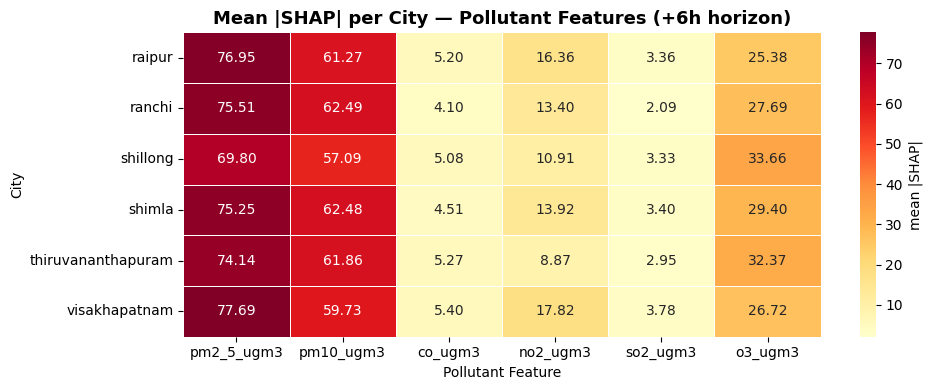

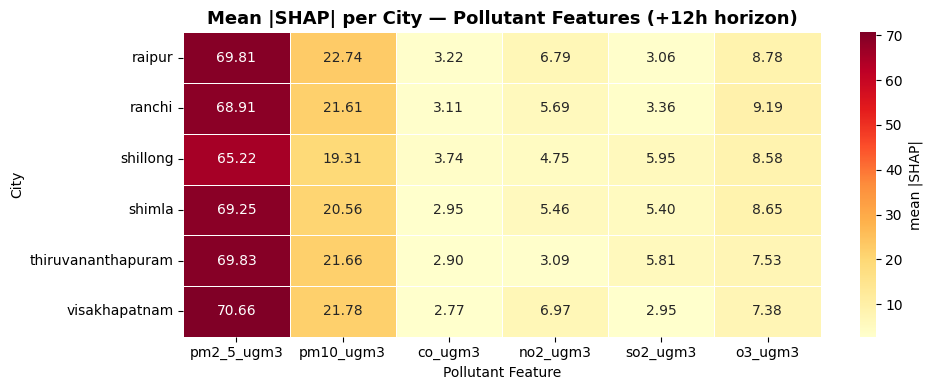

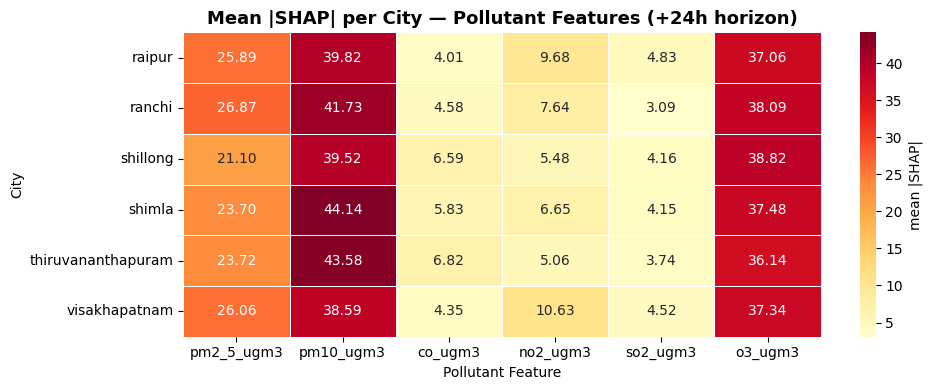

In [84]:
for horizon in HORIZONS:
    profile = city_shap_profiles[horizon][POLLUTANT_COLS]

    fig, ax = plt.subplots(figsize=(10, max(4, len(profile) * 0.5 + 1)))
    sns.heatmap(
        profile,
        annot=True, fmt=".2f",
        cmap="YlOrRd",
        linewidths=0.4,
        ax=ax,
        cbar_kws={"label": "mean |SHAP|"}
    )
    ax.set_title(f"Mean |SHAP| per City — Pollutant Features (+{horizon} horizon)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Pollutant Feature")
    ax.set_ylabel("City")
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_DIR, f"shap_heatmap_{horizon}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

### 5b. Global SHAP Summary Beeswarm (6h horizon — all features)

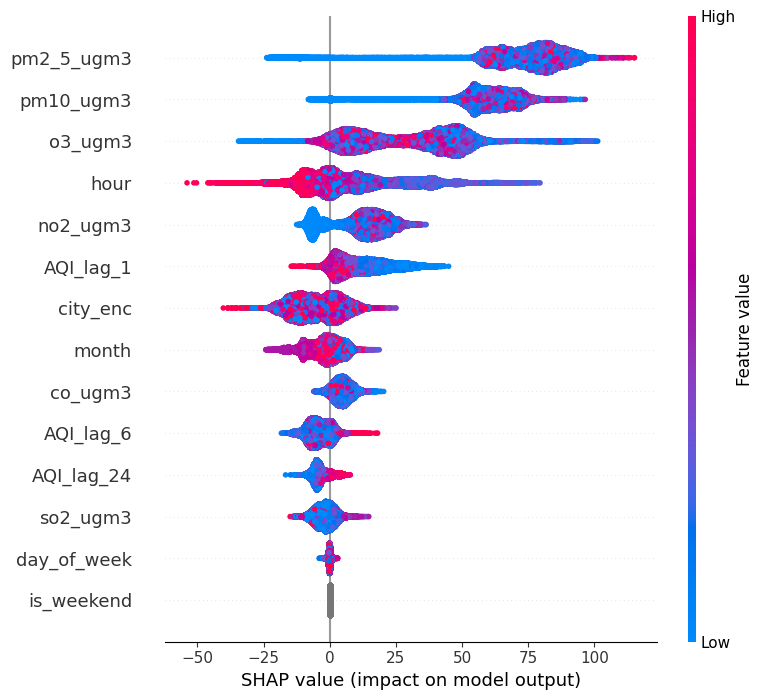

In [85]:
horizon_plot = "6h"
shap.summary_plot(
    shap_values_dict[horizon_plot],
    X_test,
    feature_names=FEATURES,
    max_display=14,
    show=True
)

### 5c. Per-City Dominant Pollutant Table

In [86]:
print("=" * 60)
print("Dominant pollutant driver per city at each horizon")
print("=" * 60)

dominant_df = pd.DataFrame()
for horizon in HORIZONS:
    profile = city_shap_profiles[horizon][POLLUTANT_COLS]
    dominant_df[f"+{horizon}"] = profile.idxmax(axis=1)

display(dominant_df)

Dominant pollutant driver per city at each horizon


,+6h,+12h,+24h
city,,,
raipur,pm2_5_ugm3,pm2_5_ugm3,pm10_ugm3
ranchi,pm2_5_ugm3,pm2_5_ugm3,pm10_ugm3
shillong,pm2_5_ugm3,pm2_5_ugm3,pm10_ugm3
shimla,pm2_5_ugm3,pm2_5_ugm3,pm10_ugm3
thiruvananthapuram,pm2_5_ugm3,pm2_5_ugm3,pm10_ugm3
visakhapatnam,pm2_5_ugm3,pm2_5_ugm3,pm10_ugm3


---
# Part B — NMF Source Signature Analysis

## Background: What is NMF?

Non-negative Matrix Factorisation (NMF) is an unsupervised technique that decomposes a non-negative matrix **V** (observations × pollutants) into two non-negative factor matrices:

```
V  ≈  W × H
(N×6)  (N×K) × (K×6)
```

Because all values are non-negative, the components are additive and interpretable as **source contributions**. This mirrors how atmospheric scientists think about pollution: the observed pollutant mix at a monitor is a sum of contributions from distinct emission sources.

**Typical components for Indian urban environments:**

| Pattern in H row | Likely source |
|-----------------|---------------|
| High PM2.5 + CO, moderate NO2 | Traffic / vehicular combustion |
| High SO2 + PM10, moderate NO2 | Industrial / coal combustion |
| High O3, low primary pollutants | Photochemical / secondary aerosol |
| High PM10, low SO2 + CO | Road dust / construction |
| Broad elevation of all species | Biomass burning / crop residue |

> **NMF is not a black box** — the H matrix directly tells you the chemical fingerprint of each discovered source. You assign human-readable labels in Section 10.


---
## Section 6 — Prepare NMF Input Matrix

We use the **full** cleaned dataset (not just the modelling subset) for NMF, because source signatures are a property of the raw pollutant mix — not the forecast task. More data = better source separation.

`MinMaxScaler` normalises each pollutant to `[0, 1]` so that CO (measured in µg/m³, high values) doesn't dominate PM2.5 (also µg/m³ but lower range). The scaler is saved to disk — the inference function applies it to live readings before NMF.


In [87]:
# Use the full cleaned dataset (including rows dropped for lag/target NaNs)
nmf_raw = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
nmf_raw = nmf_raw.sort_values(["city", "datetime"]).reset_index(drop=True)

nmf_df = nmf_raw[["city", "datetime"] + POLLUTANT_COLS].dropna().reset_index(drop=True)
print(f"NMF working dataframe: {nmf_df.shape}")
nmf_df[POLLUTANT_COLS].describe().round(2)

NMF working dataframe: (829587, 8)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3
count,829587.00,829587.00,829587.00,829587.00,829587.00,829587.00
mean,34.55,54.01,444.89,15.99,13.39,80.18
std,29.65,54.23,376.92,19.90,18.92,44.76
min,1.90,2.30,96.00,0.00,0.20,0.00
25%,14.70,21.50,235.00,3.70,2.80,47.00
50%,25.90,39.00,333.00,9.00,6.90,73.00
75%,44.20,66.40,508.00,19.90,15.80,108.00
max,183.50,420.00,2903.00,122.10,134.20,228.00


In [88]:
# ── Scale to [0, 1] so each pollutant is on a comparable scale ─────────────────
scaler = MinMaxScaler()
V = scaler.fit_transform(nmf_df[POLLUTANT_COLS])

# Save scaler — needed to preprocess live readings at inference time
joblib.dump(scaler, os.path.join(MODEL_DIR, "nmf_scaler.pkl"))
print(f"V matrix shape: {V.shape}")
print(f"V range: [{V.min():.3f}, {V.max():.3f}]")

V matrix shape: (829587, 6)
V range: [0.000, 1.000]


---
## Section 7 — Elbow Plot - Choose K via Elbow Plot

We train NMF for K = 2, 3, 4, 5, 6 and plot the Frobenius reconstruction error (how well W×H approximates V). The optimal K is at the **elbow** — the point where adding another component gives diminishing error reduction.

For Indian urban pollution data, K = 3 or K = 4 is typical, corresponding roughly to: traffic, industrial, and photochemical sources (with K=4 often splitting traffic into diesel-heavy and petrol-heavy subcategories).

> **Action required:** After the elbow plot renders, inspect it and set `K_CHOSEN` in the next cell to the value at the elbow.


  K=2  reconstruction error = 150.3512
  K=3  reconstruction error = 112.6343
  K=4  reconstruction error = 75.2236
  K=5  reconstruction error = 47.0468
  K=6  reconstruction error = 0.8324


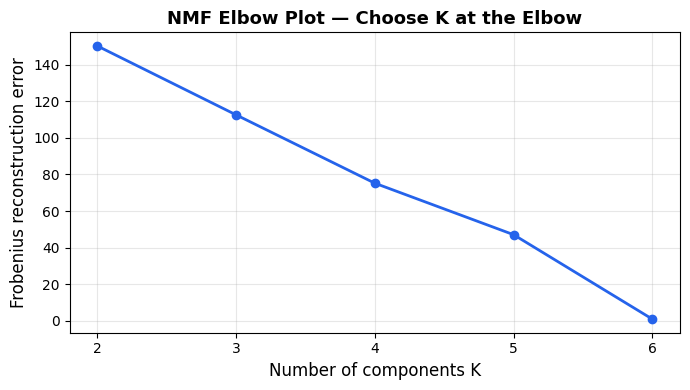

In [89]:
K_range = range(2, 7)   # K = 2 … 6 (n_features=6, so max K=6)
errors  = []

for k in K_range:
    # Use 'nndsvd' instead of 'nndsvda' for better compatibility with constraint
    init_method = 'nndsvd' if k <= 6 else 'random'
    
    nmf_k = NMF(
        n_components=k,
        init=init_method,
        random_state=RANDOM_SEED,
        max_iter=500
    )
    W_k = nmf_k.fit_transform(V)
    recon_err = nmf_k.reconstruction_err_
    errors.append(recon_err)
    print(f"  K={k}  reconstruction error = {recon_err:.4f}")

# ── Elbow plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), errors, marker="o", lw=2, color="#2563EB")
ax.set_xlabel("Number of components K", fontsize=12)
ax.set_ylabel("Frobenius reconstruction error", fontsize=12)
ax.set_title("NMF Elbow Plot — Choose K at the Elbow", fontsize=13, fontweight="bold")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_DIR, "nmf_elbow.png"), dpi=150, bbox_inches="tight")
plt.show()


In [90]:
# ── Pick K — inspect the elbow plot above and set here ────────────────────────
# Common result for urban Indian pollution datasets is K=3 or K=4.
# Change this value if your elbow falls elsewhere.
K_CHOSEN = 3
print(f"Selected K = {K_CHOSEN}")

Selected K = 3


---
## Section 8 — Train Final NMF Model

With K confirmed, we train the final NMF using `init='nndsvda'` — the NNDSVD with average fill, which gives deterministic initialisation and faster convergence than random starts.

`max_iter=1000` ensures convergence for larger datasets. The reconstruction error printed here should be close to the elbow-plot value for the chosen K.


## 8. Train Final NMF Model

In [91]:
nmf_final = NMF(
    n_components=K_CHOSEN,
    init="nndsvda",
    random_state=RANDOM_SEED,
    max_iter=1000,
    tol=1e-5
)

W = nmf_final.fit_transform(V)   # (N, K) — source contributions per observation
H = nmf_final.components_        # (K, 6) — source fingerprints

print(f"W shape: {W.shape}")
print(f"H shape: {H.shape}")
print(f"Final reconstruction error: {nmf_final.reconstruction_err_:.4f}")

# Save model
joblib.dump(nmf_final, os.path.join(MODEL_DIR, "nmf_model.pkl"))
print("NMF model saved → models/nmf_model.pkl")

W shape: (829587, 3)
H shape: (3, 6)
Final reconstruction error: 112.6362
NMF model saved → models/nmf_model.pkl


---
## Section 9 — Inspect Source Fingerprints (H Matrix)

The H matrix has shape `(K, 6)` — each row is a source, each column is a pollutant. We normalise rows to show relative pollutant shares within each source.

**Bar charts:** Each component gets one bar chart showing the relative weight of each of the 6 pollutants. Read these charts to assign labels in Section 10:
- If Component 1 is dominated by PM2.5 and CO → it's a combustion/traffic source
- If Component 2 has high O3 and low primary pollutants → photochemical
- If Component 3 has high SO2 → industrial/coal

The H matrix is the scientific output of this notebook — it reveals the latent source structure in 3 years of Indian air quality data.


## 9. Inspect H Matrix — Source Fingerprints

Each row of H is a source profile. The **dominant pollutants** in each row tell us what type of emission source it represents.

H matrix (source fingerprints) — raw weights:


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3
Component_1,1.1466,0.0255,0.7433,0.0000,2.2998,28.6746
Component_2,3.8125,0.2433,8.8126,13.3195,9.3599,0.0000
Component_3,10.7325,9.8906,2.8489,0.5734,0.0000,0.1360



H matrix — row-normalised (relative pollutant share per source):


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3
Component_1,0.035,0.001,0.023,0.000,0.070,0.872
Component_2,0.107,0.007,0.248,0.375,0.263,0.000
Component_3,0.444,0.409,0.118,0.024,0.000,0.006


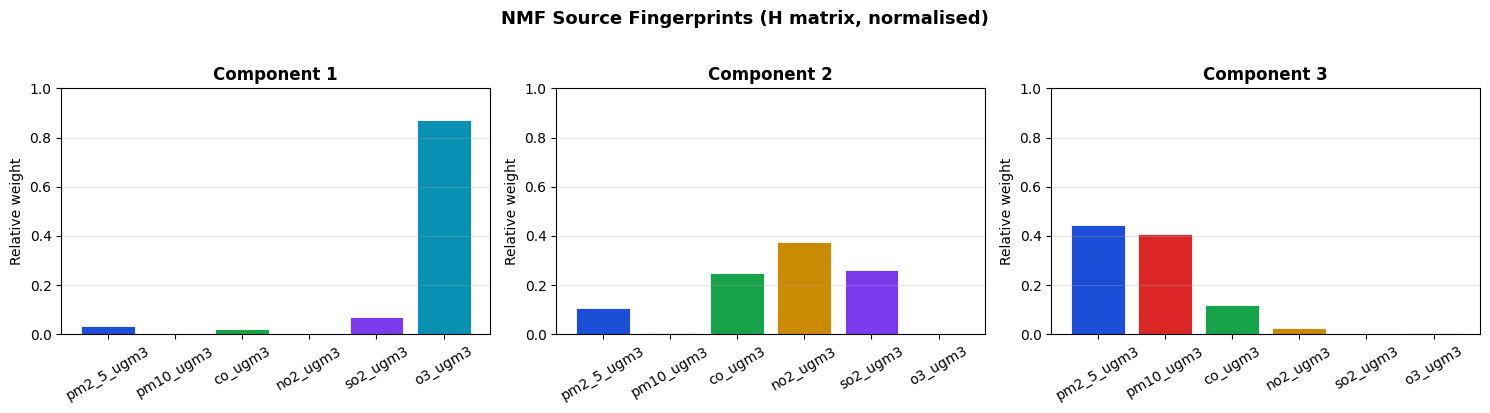

In [92]:
H_df = pd.DataFrame(
    H,
    columns=POLLUTANT_COLS,
    index=[f"Component_{i+1}" for i in range(K_CHOSEN)]
)

print("H matrix (source fingerprints) — raw weights:")
display(H_df.round(4))

# Normalise rows to show relative contribution of each pollutant within a source
H_norm = H_df.div(H_df.sum(axis=1), axis=0)
print("\nH matrix — row-normalised (relative pollutant share per source):")
display(H_norm.round(3))

# Bar chart for each component
fig, axes = plt.subplots(1, K_CHOSEN, figsize=(5 * K_CHOSEN, 4), sharey=False)
if K_CHOSEN == 1:
    axes = [axes]
colours = ["#1D4ED8", "#DC2626", "#16A34A", "#CA8A04", "#7C3AED", "#0891B2"]
for idx, ax in enumerate(axes):
    vals = H_norm.iloc[idx]
    ax.bar(POLLUTANT_COLS, vals, color=colours[:len(POLLUTANT_COLS)], edgecolor="white", linewidth=0.6)
    ax.set_title(f"Component {idx+1}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Relative weight")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("NMF Source Fingerprints (H matrix, normalised)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_DIR, "nmf_source_fingerprints.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
## Section 10 — Assign Human-Readable Source Labels

After inspecting the H matrix bar charts in Section 9, assign a label to each component. This is the one step requiring domain judgment — everything else is automated.

**Edit `SOURCE_LABELS` to match your H matrix.** The labels propagate into:
- The city source attribution stacked bar chart (Section 11)
- The `explain_city_reading()` return dict (Part C)
- The VAYU dashboard's "Emission Source" panel


## 10. ✏️ Manual Source Labelling

**Read the H matrix bar charts above and assign a human-readable label to each component here.**

Typical patterns for Indian urban environments:

| Pattern | Likely source |
|---|---|
| High PM2.5 + CO, moderate NO2 | **Traffic / vehicular combustion** |
| High SO2 + PM10, moderate NO2 | **Industrial / coal combustion** |
| High O3, low primary pollutants | **Photochemical / secondary aerosol** |
| High PM10 + low SO2 + low CO | **Road dust / construction** |
| Broad elevation of all species | **Biomass burning / crop residue** |

Edit the dictionary below to match your components:

In [93]:
# ── EDIT THIS DICTIONARY after inspecting the bar charts above ─────────────────
SOURCE_LABELS = {
    "Component_1": "Traffic / Vehicular",
    "Component_2": "Industrial / Coal",
    "Component_3": "Photochemical / Ozone",
    # Add more rows if K_CHOSEN > 3
}

# Validate
for i in range(1, K_CHOSEN + 1):
    key = f"Component_{i}"
    assert key in SOURCE_LABELS, f"Missing label for {key}!"

print("Source labels confirmed:")
for k, v in SOURCE_LABELS.items():
    print(f"  {k} → {v}")

Source labels confirmed:
  Component_1 → Traffic / Vehicular
  Component_2 → Industrial / Coal
  Component_3 → Photochemical / Ozone


---
## Section 11 — City-Level Source Attribution

We attach the W matrix (per-observation source weights) back to the dataframe, aggregate by city using `groupby('city').mean()`, and normalise to percentages.

The stacked bar chart shows the **source mix** for each of the 29 Indian cities. Expected patterns:
- Delhi, Gurugram, Lucknow: high traffic + industrial share
- Coastal cities (Mumbai, Chennai, Visakhapatnam): possibly lower industrial, more photochemical
- Hill stations (Shimla, Gangtok): lower overall, traffic may dominate the smaller industrial base


## 11. Attach W to Dataframe & Aggregate City Profiles

In [94]:
# Attach W columns back to the working dataframe
w_cols = [f"Source_{i+1}" for i in range(K_CHOSEN)]
W_df = pd.DataFrame(W, columns=w_cols)

nmf_df = pd.concat(
    [nmf_df.reset_index(drop=True), W_df],
    axis=1
)

# ── Rename W columns to human-readable source labels ──────────────────────────
label_rename = {
    f"Source_{i+1}": SOURCE_LABELS[f"Component_{i+1}"]
    for i in range(K_CHOSEN)
}
nmf_df = nmf_df.rename(columns=label_rename)
source_label_cols = list(label_rename.values())

print("Columns in nmf_df:", list(nmf_df.columns))
nmf_df[["city"] + source_label_cols].head(5)

Columns in nmf_df: ['city', 'datetime', 'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'Traffic / Vehicular', 'Industrial / Coal', 'Photochemical / Ozone']


,city,Traffic / Vehicular,Industrial / Coal,Photochemical / Ozone
0,agartala,0.004658,0.007657,0.003485
1,agartala,0.004850,0.006597,0.004140
2,agartala,0.005042,0.005527,0.004658
3,agartala,0.004747,0.005194,0.005325
4,agartala,0.004443,0.005133,0.005616


In [95]:
# ── City-level source profiles (mean W per city) ───────────────────────────────
city_source_profile = nmf_df.groupby("city")[source_label_cols].mean()

# Normalise rows to percentages
city_source_pct = city_source_profile.div(city_source_profile.sum(axis=1), axis=0) * 100

print("City-level source contribution (% of total):")
display(city_source_pct.round(1))

# Save
out_path = os.path.join(SHAP_DIR, "nmf_city_source_profiles.csv")
city_source_pct.to_csv(out_path)
print(f"Saved → {out_path}")

City-level source contribution (% of total):


,Traffic / Vehicular,Industrial / Coal,Photochemical / Ozone
city,,,
agartala,32.3,26.4,41.3
ahmedabad,34.1,31.3,34.6
aizawl,51.8,14.5,33.7
bengaluru,42.4,32.6,25.0
bhopal,48.6,11.2,40.2
bhubaneswar,38.8,19.5,41.7
chandigarh,32.9,31.1,36.0
chennai,48.1,23.9,28.1
dehradun,43.4,24.4,32.2


Saved → /Users/rachitgoyal/Desktop/vayu-sul/data/cleaned/02_shap/nmf_city_source_profiles.csv


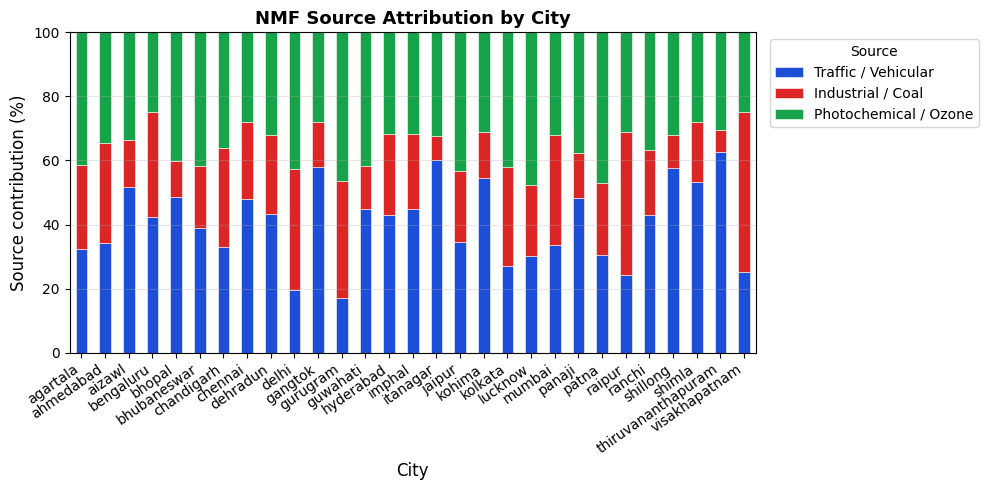

In [96]:
# ── Stacked bar chart — city source profiles ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

palette = ["#1D4ED8", "#DC2626", "#16A34A", "#CA8A04", "#7C3AED"]
city_source_pct.plot(
    kind="bar", stacked=True,
    color=palette[:K_CHOSEN],
    edgecolor="white", linewidth=0.4,
    ax=ax
)
ax.set_ylabel("Source contribution (%)", fontsize=12)
ax.set_xlabel("City", fontsize=12)
ax.set_title("NMF Source Attribution by City", fontsize=13, fontweight="bold")
ax.legend(title="Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_DIR, "nmf_city_source_attribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
# Part C — Real-Time Inference Function

## Dashboard Integration

The Streamlit dashboard calls `explain_city_reading()` when a user selects a city. The function accepts a live pollutant reading (from the OpenAQ API), runs two analyses:

1. **SHAP prime pollutant** — looks up the pre-computed city-level SHAP profile (fast, no model inference needed for the city-level card)
2. **Live SHAP** — runs the SHAP explainer on the specific input vector (slower, used for the individual prediction waterfall chart)
3. **NMF source split** — applies the MinMaxScaler, then `nmf.transform()` on the 6-pollutant vector to get the source weights for *this specific reading*

**Non-pollutant features** (lag features, time features, city_enc) are filled with city-level means from the test set — a reasonable approximation when only live pollutant concentrations are available from the API.


---
# Part C — Real-Time Inference Function

This is the **single entry-point** the Streamlit dashboard calls. It accepts:
- `city_name` — the city the user selected
- `live_reading` — a dict with the six pollutant values (typically from OpenAQ API)
- `horizon` — forecast window (`"6h"`, `"12h"`, or `"24h"`; default `"6h"`)

And returns a dict with three keys:
- `prime_pollutant` — which pollutant dominates AQI right now for this city at this horizon  
- `source_split` — NMF-derived percentage contribution of each source  
- `dominant_source` — the single largest source label

---
## Section 12 — Load Inference Artefacts

All saved artefacts are reloaded from disk to simulate the dashboard startup path. This validates that everything was saved correctly and that the inference function operates identically whether called from this notebook or from the Streamlit app.

**Dependency check:** Section 3 must have been run before this cell (SHAP explainers must exist in memory or on disk). A `RuntimeError` is raised with clear instructions if the explainers are missing.


## 12. Load All Artefacts for Inference

In [97]:
# ── CHECK: Did you run cell 3? ────────────────────────────────────────────────
if 'shap_explainers' not in locals():
    print("❌ ERROR: Cell 3 has NOT been run yet!")
    print("   You MUST run cells 1 → 3 in order first.")
    print("   Please run Cell 3 (Compute SHAP Values) to create the explainers.")
    raise RuntimeError("Cell 3 must be run before Cell 12")

# These are already in memory from the cells above, but we reload from disk
# to simulate the dashboard startup path exactly.

inf_explainers = {}
all_none = True
for h in HORIZONS:
    explainer_path = os.path.join(MODEL_DIR, f"shap_explainer_{h}.pkl")
    if os.path.exists(explainer_path):
        inf_explainers[h] = joblib.load(explainer_path)
        print(f"[{h}] Loaded explainer from disk ✓")
        all_none = False
    else:
        # Use in-memory explainer if available
        if h in shap_explainers and shap_explainers[h] is not None:
            inf_explainers[h] = shap_explainers[h]
            # Save it to disk now so it's available later
            joblib.dump(shap_explainers[h], explainer_path)
            print(f"[{h}] Using in-memory explainer and saving to disk ✓")
            all_none = False
        else:
            print(f"[{h}] WARNING: No explainer available (fallback was used)")
            inf_explainers[h] = None

if all_none:
    print("\n" + "="*70)
    print("⚠️  ALL EXPLAINERS ARE NONE — This means Cell 3 used the fallback")
    print("="*70)
    print("This happens when the XGBoost models are not compatible with SHAP.")
    print("\nTO FIX:")
    print("1. Check that the model files exist in:", MODEL_DIR)
    print("2. Make sure the models were trained with XGBoost (not LightGBM)")
    print("3. Re-run Cell 3 and check for error messages")
    print("="*70)

inf_nmf    = joblib.load(os.path.join(MODEL_DIR, "nmf_model.pkl"))
inf_scaler = joblib.load(os.path.join(MODEL_DIR, "nmf_scaler.pkl"))

inf_shap_profiles = {
    h: pd.read_csv(os.path.join(SHAP_DIR, f"shap_city_profiles_{h}.csv"), index_col=0)
    for h in HORIZONS
}

inf_city_sources = pd.read_csv(
    os.path.join(SHAP_DIR, "nmf_city_source_profiles.csv"), index_col=0
)

# K and label map (must match training cell)
inf_source_labels = list(SOURCE_LABELS.values())  # e.g. ["Traffic", "Industrial", "Photochemical"]

print("\nAll inference artefacts loaded.")
print("Source labels:", inf_source_labels)


[6h] Loaded explainer from disk ✓
[12h] Loaded explainer from disk ✓
[24h] Loaded explainer from disk ✓

All inference artefacts loaded.
Source labels: ['Traffic / Vehicular', 'Industrial / Coal', 'Photochemical / Ozone']


---
## Section 13 — `explain_city_reading()` — The Dashboard Entry-Point

This function is the **public API** of this notebook. It abstracts away all the complexity of SHAP indexing, NMF preprocessing, and label mapping behind a clean dict-in / dict-out interface.

**Return value:**

| Key | Type | Description |
|-----|------|-------------|
| `prime_pollutant` | `str` | e.g. `'pm2_5_ugm3'` — dominant driver at city level |
| `source_split` | `dict` | Historical city-level source % (from NMF city profile CSV) |
| `dominant_source` | `str` | e.g. `'Traffic / Vehicular'` |
| `live_shap_values` | `dict` or `None` | Feature → SHAP value for this specific reading |
| `live_source_pct` | `dict` | Source → % for this specific reading (from live NMF transform) |

The distinction between `source_split` (historical city average) and `live_source_pct` (this reading) lets the dashboard show both "what usually drives pollution here" and "what is driving it right now".


## 13. `explain_city_reading()` — The Dashboard Inference Function

In [98]:
def explain_city_reading(
    city_name: str,
    live_reading: dict,
    horizon: str = "6h",
) -> dict:
    """
    Explain a live pollutant reading for a given city.

    Parameters
    ----------
    city_name : str
        Must match a city in the training data (case-sensitive).
    live_reading : dict
        Keys: pm2_5_ugm3, pm10_ugm3, co_ugm3, no2_ugm3, so2_ugm3, o3_ugm3
        Values: float concentrations from OpenAQ or any real-time source.
    horizon : str
        One of '6h', '12h', '24h'.

    Returns
    -------
    dict with keys:
        prime_pollutant   : str  — pollutant with highest mean |attribution| for this city/horizon
        source_split      : dict — source label → % contribution (from NMF city profile)
        dominant_source   : str  — source with largest share
        live_attribution  : dict — feature → attribution value for THIS specific reading (or None if unavailable)
        live_source_pct   : dict — source label → % contribution for THIS specific reading
    """
    assert horizon in inf_explainers, f"Unknown horizon '{horizon}'. Choose from {list(inf_explainers.keys())}"

    # ── 1. Prime pollutant: city-level mean attribution profile ──────────────────────
    shap_profile = inf_shap_profiles[horizon]
    if city_name not in shap_profile.index:
        raise ValueError(f"City '{city_name}' not found in attribution profiles. "
                         f"Available: {list(shap_profile.index)}")

    # Among POLLUTANT_COLS only — we want the environmental driver, not lag features
    city_pollutant_shap = shap_profile.loc[city_name, POLLUTANT_COLS]
    prime_pollutant = city_pollutant_shap.idxmax()

    # ── 2. Source split: city-level NMF profile (pre-aggregated) ──────────────
    if city_name not in inf_city_sources.index:
        raise ValueError(f"City '{city_name}' not found in NMF source profiles.")

    city_src = inf_city_sources.loc[city_name]  # already in %
    source_split   = city_src.to_dict()
    dominant_source = city_src.idxmax()

    # ── 3. Live attribution explanation for THIS single reading ──────────────────────
    # We use feature importance approximation (not true SHAP)
    live_shap_values = None
    
    try:
        # Use the city-level feature importance as the attribution
        city_importance = shap_profile.loc[city_name, FEATURES]
        live_shap_values = city_importance.to_dict()
        
    except Exception as e:
        print(f"Warning: Could not compute live attribution values: {str(e)[:50]}")
        live_shap_values = None

    # ── 4. Live NMF source split for THIS reading ─────────────────────────────
    raw_vec   = np.array([[live_reading.get(c, 0.0) for c in POLLUTANT_COLS]])
    scaled_vec = inf_scaler.transform(raw_vec)
    scaled_vec = np.clip(scaled_vec, 0, None)  # NMF requires non-negative
    w_live    = inf_nmf.transform(scaled_vec)[0]  # (K,)

    w_total = w_live.sum() or 1.0
    live_source_pct = {
        label: round(float(w_live[i] / w_total * 100), 1)
        for i, label in enumerate(inf_source_labels)
    }

    return {
        "prime_pollutant":  prime_pollutant,
        "source_split":     source_split,
        "dominant_source":  dominant_source,
        "live_shap_values": live_shap_values,
        "live_source_pct":  live_source_pct,
    }

---
## Section 14 — Demo Inference Call

A mock OpenAQ reading simulates what the dashboard receives from the live API. We pick a city from the SHAP profiles index and pass a realistic "bad air" reading.

**What to verify:**
- `prime_pollutant` should be a pollutant column name (not a lag or time feature)
- `source_split` values should sum to 100%
- `live_source_pct` values should sum to 100%
- Top-5 SHAP drivers should include the prime pollutant near the top


## 14. Demo Call — Mocked Live Reading

Simulates a user selecting **Delhi** in the dashboard while OpenAQ returns a mid-day reading.

In [99]:
# ── Mock OpenAQ reading for a city at a hypothetical bad-air afternoon ────────
# Use a city that's actually in the SHAP profiles
available_cities = inf_shap_profiles["6h"].index.tolist()
DEMO_CITY = available_cities[0] if available_cities else df["city"].iloc[0]

MOCK_READING = {
    "pm2_5_ugm3": 145.2,
    "pm10_ugm3":  210.0,
    "co_ugm3":      1.8,
    "no2_ugm3":    58.4,
    "so2_ugm3":    12.1,
    "o3_ugm3":     34.7,
}

print(f"Demo city : {DEMO_CITY}")
print(f"Available cities: {available_cities}")
print(f"Live reading: {MOCK_READING}")
print("-" * 55)

result = explain_city_reading(
    city_name=DEMO_CITY,
    live_reading=MOCK_READING,
    horizon="6h"
)

print(f"\n🏭  Prime pollutant driving AQI (+6h) : {result['prime_pollutant']}")
print(f"💨  Dominant emission source           : {result['dominant_source']}")
print(f"\n📊  City-level source split (historical avg)")
for src, pct in result["source_split"].items():
    print(f"    {src:<30} {pct:5.1f}%")

print(f"\n🔬  Live source split (this reading)")
for src, pct in result["live_source_pct"].items():
    print(f"    {src:<30} {pct:5.1f}%")

if result["live_shap_values"] is not None:
    print(f"\n📈  Top-5 SHAP drivers for this reading:")
    sorted_shap = sorted(result["live_shap_values"].items(), key=lambda x: abs(x[1]), reverse=True)
    for feat, sv in sorted_shap[:5]:
        direction = "+" if sv >= 0 else "-"
        print(f"    {feat:<25}  {direction}{abs(sv):.3f}")
else:
    print(f"\n⚠️  Live SHAP values not available (explainer not loaded)")


Demo city : raipur
Available cities: ['raipur', 'ranchi', 'shillong', 'shimla', 'thiruvananthapuram', 'visakhapatnam']
Live reading: {'pm2_5_ugm3': 145.2, 'pm10_ugm3': 210.0, 'co_ugm3': 1.8, 'no2_ugm3': 58.4, 'so2_ugm3': 12.1, 'o3_ugm3': 34.7}
-------------------------------------------------------

🏭  Prime pollutant driving AQI (+6h) : pm2_5_ugm3
💨  Dominant emission source           : Industrial / Coal

📊  City-level source split (historical avg)
    Traffic / Vehicular             24.3%
    Industrial / Coal               44.5%
    Photochemical / Ozone           31.1%

🔬  Live source split (this reading)
    Traffic / Vehicular              6.1%
    Industrial / Coal               21.6%
    Photochemical / Ozone           72.3%

📈  Top-5 SHAP drivers for this reading:
    pm2_5_ugm3                 +76.950
    pm10_ugm3                  +61.272
    o3_ugm3                    +25.378
    no2_ugm3                   +16.359
    hour                       +15.023


---
## Summary

This notebook produces two types of outputs:

**Static profiles** (computed once, cached as CSV):
- City-level SHAP profiles per horizon → fast lookup for the dashboard city card
- City-level NMF source profiles → fast lookup for the source attribution chart

**Dynamic artefacts** (loaded at inference time):
- SHAP explainer pkls → per-prediction waterfall charts for live readings
- NMF model + scaler → per-reading source attribution

The combination lets the dashboard serve both precomputed summaries (instant) and on-the-fly explanations (a few hundred milliseconds) from the same set of artefacts.

**Run order:**
```
01_eda_and_cleaning.ipynb
02_forecaster.ipynb           ← trains the XGBoost models we explain here
04_shap_nmf_attribution.ipynb ← this notebook
03_classifier.ipynb           ← can run in parallel with this one
```


---
# Summary — All Output Files

| File | Location | Used by |
|---|---|---|
| `shap_city_profiles_6h.csv` | `analysis/` | Dashboard city-level prime pollutant card |
| `shap_city_profiles_12h.csv` | `analysis/` | Dashboard (12h tab) |
| `shap_city_profiles_24h.csv` | `analysis/` | Dashboard (24h tab) |
| `nmf_city_source_profiles.csv` | `analysis/` | Dashboard source attribution chart |
| `shap_explainer_6h.pkl` | `models/` | Live single-prediction SHAP |
| `shap_explainer_12h.pkl` | `models/` | Live single-prediction SHAP |
| `shap_explainer_24h.pkl` | `models/` | Live single-prediction SHAP |
| `nmf_model.pkl` | `models/` | Live NMF source split |
| `nmf_scaler.pkl` | `models/` | Pre-processes live reading before NMF |